# Oasis Infobyte Internship

# Level 1 - Task 4

# Sentiment Analysis

## Objective

## Import Libraries

## Load Dataset

## Explore Dataset

## Data Preprocessing

## Feature Extraction using TF-IDF

## Train-Test Split

## Model Training

## Model Evaluation

## Visualizations

## Conclusion

In this section, we import the libraries required for data manipulation, visualization, text preprocessing, machine learning, and model evaluation.

In [24]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In this section, we load the IMDb movie reviews dataset into a pandas DataFrame and display the first few records to understand its structure.

In [25]:
df = pd.read_csv("IMDB Dataset.csv", engine="python")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Explore Dataset

In this section, we check the size of the dataset to know how many rows and columns it contains.

In [26]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (50000, 2)


### Dataset Information

In this section, we check the dataset's structure, data types, and whether there are any missing values.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### Missing Values

In this section, we check whether the dataset contains any missing (null) values.

In [28]:
df.isnull().sum()

,0
review,0
sentiment,0


**Observation:**

- The dataset contains no missing values.
- Both the `review` and `sentiment` columns have 50,000 non-null entries.
- Therefore, no missing value treatment is required.

### Sentiment Distribution

In this section, we check the number of positive and negative reviews present in the dataset.

In [29]:
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


**Observation:**

- The dataset contains an equal number of positive and negative reviews.
- There are 25,000 positive reviews and 25,000 negative reviews.
- Since the dataset is balanced, it is suitable for training a machine learning model without class imbalance issues.

### Visualization of Sentiment Distribution

A count plot is used to visualize the distribution of positive and negative reviews in the dataset.

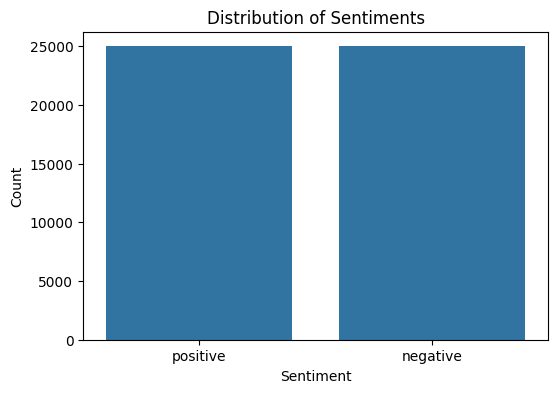

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)

plt.title("Distribution of Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

**Observation:**

- The count plot shows that the dataset is evenly distributed between positive and negative reviews.
- Both classes contain 25,000 reviews each.
- This balanced distribution helps in building a fair and unbiased machine learning model.

## Data Preprocessing

In this section, we clean the review text by removing unnecessary characters and converting it into a format suitable for machine learning.

In [31]:
df["review"][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

### Text Cleaning

The review text is cleaned by converting it to lowercase and removing HTML tags. This helps prepare the text for machine learning.

In [32]:
import re
import string

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    return text

### Testing the Cleaning Function

Before applying the cleaning function to the entire dataset, we test it on a single review to verify that it works correctly.


In [33]:
clean_text(df["review"][0])

'one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with methe first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the wordit is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far awayi would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictur

**Observation:**

- The cleaning function successfully converted all text to lowercase.
- HTML tags such as `<br />` were removed.
- Punctuation marks were also removed from the review text.
- The review text is now cleaner and ready for feature extraction.

### Removing Punctuation

Punctuation marks are removed from the review text because they usually do not contribute to sentiment classification and can increase noise in the dataset.

### Applying Text Cleaning

The cleaning function is applied to all reviews in the dataset to create a cleaned version of the review text for machine learning.

In [34]:
df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...


**Observation:**

- A new column named `clean_review` was created.
- The original review text was preserved, while the cleaned review text was stored separately.
- The cleaned reviews will be used for feature extraction and model training.

## Feature Extraction using TF-IDF

Machine learning algorithms cannot understand raw text directly. Therefore, the cleaned review text is converted into numerical features using the TF-IDF (Term Frequency–Inverse Document Frequency) technique.

In [35]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

### Converting Text into Numerical Features

The TF-IDF vectorizer is applied to the cleaned review text to convert textual data into numerical feature vectors that can be used for machine learning.

In [36]:
X = tfidf.fit_transform(df["clean_review"])

X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3362864 stored elements and shape (50000, 5000)>

**Observation:**

- The cleaned review text was successfully converted into numerical feature vectors using TF-IDF.
- The resulting feature matrix has 50,000 rows and 5,000 columns.
- A sparse matrix was created to efficiently store the numerical features.

### Preparing Target Variable

The sentiment column is used as the target variable, where each review is labeled as either positive or negative.

In [37]:
y = df["sentiment"]

y.head()

,sentiment
0,positive
1,positive
2,positive
3,negative
4,positive


**Observation:**

- The `sentiment` column was selected as the target variable (`y`).
- It contains two classes: **positive** and **negative**.
- These labels will be used to train the machine learning model.

## Train-Test Split

The dataset is divided into training and testing sets. The training data is used to build the model, while the testing data is used to evaluate its performance.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Checking the Shape of Training and Testing Data

The shapes of the training and testing datasets are checked to verify that the data has been split correctly.

In [39]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (40000, 5000)
Testing Data : (10000, 5000)


**Observation:**

- The dataset was successfully divided into training and testing sets.
- The training dataset contains **40,000** reviews, while the testing dataset contains **10,000** reviews.
- The split ensures that the model is evaluated on unseen data.

## Model Training

A Multinomial Naive Bayes classifier is trained using the TF-IDF feature vectors. This algorithm is widely used for text classification tasks such as sentiment analysis.

In [40]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

**Observation:**

- The Multinomial Naive Bayes model was successfully trained using the training dataset.
- The model is now ready to predict the sentiment of unseen reviews.

## Making Predictions

The trained model is used to predict the sentiment of the reviews in the testing dataset.

In [42]:
y_pred = model.predict(X_test)

y_pred[:10]

array(['negative', 'positive', 'negative', 'positive', 'negative',
       'positive', 'positive', 'negative', 'negative', 'negative'],
      dtype='<U8')

**Observation:**

- The trained model successfully predicted the sentiments of the testing dataset.
- The predictions consist of two classes: **positive** and **negative**.
- These predicted values will now be compared with the actual sentiments to evaluate the model's performance.

## Model Evaluation

The performance of the trained model is evaluated using accuracy, confusion matrix, and classification report.

In [43]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8486


**Observation:**

- The trained model achieved an accuracy of **84.86%** on the testing dataset.
- This indicates that the model correctly classified approximately 85 out of every 100 movie reviews.
- The result shows that the model performs well for sentiment classification.

### Confusion Matrix

A confusion matrix is used to compare the actual sentiments with the predicted sentiments and identify correct and incorrect classifications.

In [44]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[4188,  773],
       [ 741, 4298]])

**Observation:**

- The confusion matrix shows that the majority of reviews were classified correctly.
- The model correctly predicted 4,188 negative reviews and 4,298 positive reviews.
- A small number of reviews were misclassified, indicating good overall performance.

### Confusion Matrix Heatmap

A heatmap is used to visualize the confusion matrix, making it easier to understand the model's predictions.

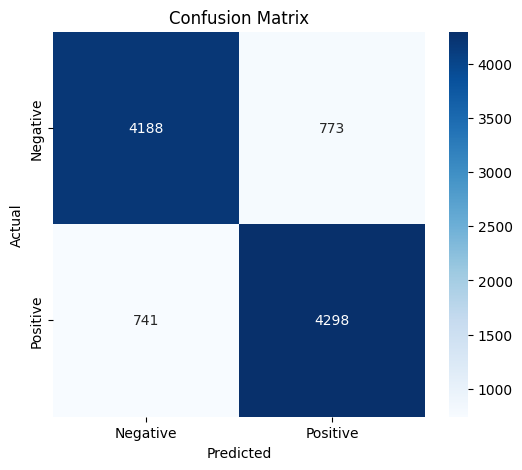

In [45]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Observation:**

- The heatmap clearly shows the distribution of correct and incorrect predictions.
- Most predictions lie on the main diagonal, indicating that the model classified the majority of reviews correctly.
- This confirms the good performance of the Multinomial Naive Bayes classifier.

### Classification Report

The classification report provides detailed performance metrics, including precision, recall, F1-score, and support for each sentiment class.

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      4961
    positive       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



**Observation:**

- The classification report shows that the model achieved good precision, recall, and F1-score for both positive and negative sentiments.
- The overall accuracy of the model is **84.86%**.
- The balanced performance across both classes indicates that the model is reliable for sentiment classification.

# Conclusion

In this project, sentiment analysis was successfully performed on the IMDb movie reviews dataset using Natural Language Processing (NLP) techniques.

The review text was cleaned through preprocessing by converting it to lowercase, removing HTML tags, and eliminating punctuation. The cleaned text was then converted into numerical features using the TF-IDF vectorization technique.

A Multinomial Naive Bayes classifier was trained on the processed data and achieved an accuracy of **84.86%** on the test dataset. The confusion matrix and classification report showed balanced performance for both positive and negative sentiments.

Overall, the project demonstrates how machine learning can effectively classify text into positive and negative sentiments using NLP techniques.